### Evaluation - homework

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv")

In [3]:
df

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1
...,...,...,...,...,...,...,...,...,...
1457,referral,manufacturing,1,NaN,self_employed,north_america,4,0.53,1
1458,referral,technology,3,65259.0,student,europe,2,0.24,1
1459,paid_ads,technology,1,45688.0,student,north_america,3,0.02,1
1460,referral,NaN,5,71016.0,self_employed,north_america,0,0.25,1


In [4]:
df.describe()

,number_of_courses_viewed,annual_income,interaction_count,lead_score,converted
count,1462.000000,1281.000000,1462.000000,1462.000000,1462.000000
mean,2.031464,59886.273224,2.976744,0.506108,0.619015
std,1.449717,15070.140389,1.681564,0.288465,0.485795
min,0.000000,13929.000000,0.000000,0.000000,0.000000
25%,1.000000,49698.000000,2.000000,0.262500,0.000000
50%,2.000000,60148.000000,3.000000,0.510000,1.000000
75%,3.000000,69639.000000,4.000000,0.750000,1.000000
max,9.000000,109899.000000,11.000000,1.000000,1.000000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               1334 non-null   str    
 1   industry                  1328 non-null   str    
 2   number_of_courses_viewed  1462 non-null   int64  
 3   annual_income             1281 non-null   float64
 4   employment_status         1362 non-null   str    
 5   location                  1399 non-null   str    
 6   interaction_count         1462 non-null   int64  
 7   lead_score                1462 non-null   float64
 8   converted                 1462 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 102.9 KB


In [6]:
cat = ['lead_source', 'industry', 'employment_status', 'location']
num = ['number_of_courses_viewed', 'annual_income', 'interaction_count', 'lead_score']

In [7]:
for col in cat:
    df[col] = df[col].fillna('NA')
for col in num:
    df[col] = df[col].fillna(0)

In [8]:
from sklearn.model_selection import train_test_split
full_train_df, test_df = train_test_split(df, test_size=0.2, random_state=1)

In [9]:
train_df, val_df = train_test_split(full_train_df, test_size=0.25, random_state=1)

In [10]:
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [11]:
y_train = train_df['converted']
y_val = val_df['converted']
y_test = test_df['converted']

#### Question 1: ROC AUC feature importance

In [12]:
from sklearn.metrics import roc_auc_score, roc_curve

In [13]:
for col in num:
    print(f"{col}: {roc_auc_score(train_df['converted'], train_df[col])}")

number_of_courses_viewed: 0.7635680590007088
annual_income: 0.5519578313253012
interaction_count: 0.738270176293409
lead_score: 0.6144993577250176


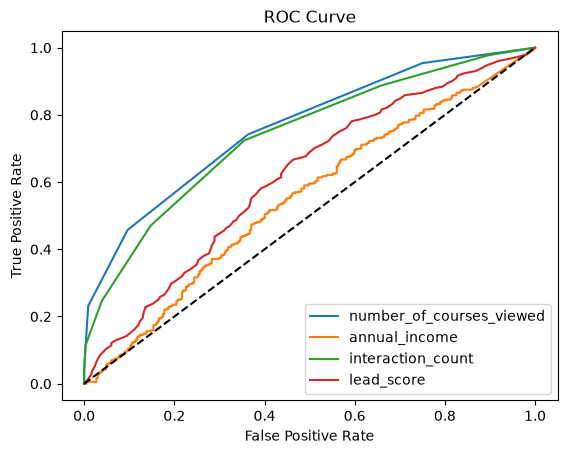

In [14]:
import matplotlib.pyplot as plt
for col in num:
    fpr, tpr, _ = roc_curve(train_df['converted'], train_df[col])
    plt.plot(fpr, tpr, label=col, color='C'+str(num.index(col)))
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line for random classifier
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

#### Question 2: Training the model

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction import DictVectorizer

In [16]:
def train_logistics_regresstion(X, y, C=1.0):
    dicts = X[num + cat].to_dict(orient='records')
    dv = DictVectorizer(sparse=False)
    X = dv.fit_transform(dicts)
    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    model.fit(X, y)
    return model, dv


In [17]:
def predict_logistics_regression(model, dv, X):
    dicts = X[num + cat].to_dict(orient='records')
    X = dv.transform(dicts)
    return model.predict_proba(X)[:, 1]

In [18]:
model, dv = train_logistics_regresstion(train_df, y_train)

In [19]:
y_val_pred = predict_logistics_regression(model, dv, val_df)

In [20]:
print(roc_auc_score(y_val, y_val_pred))

0.8171316268814112


#### Question 3: Precision and Recall

In [21]:
true_positive = (y_val == 1)
true_negative = (y_val == 0)

In [22]:
thresholds = np.linspace(0, 1, 101)

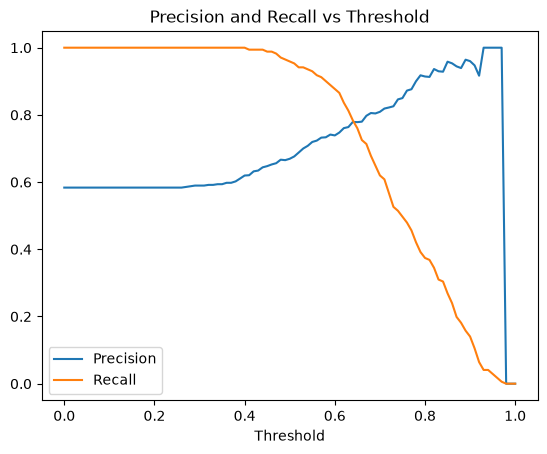

In [23]:
precisions = []
recalls = []
for t in thresholds:
    tp = ((y_val_pred >= t) & true_positive).sum()
    fp = ((y_val_pred >= t) & true_negative).sum()
    fn = ((y_val_pred < t) & true_positive).sum()
    tn = ((y_val_pred < t) & true_negative).sum()   
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precisions.append(precision)
    recalls.append(recall)
plt.plot(thresholds, precisions, label = "Precision")
plt.plot(thresholds, recalls, label = "Recall")
plt.xlabel('Threshold')
plt.title('Precision and Recall vs Threshold')
plt.legend()
plt.show()

In [24]:
from sklearn.metrics import precision_recall_curve
precision, recall, threshold = precision_recall_curve(y_val, y_val_pred)

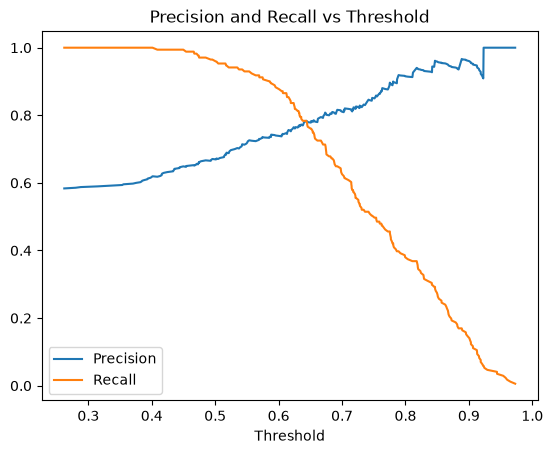

In [25]:
plt.plot(threshold, precision[:-1], label = "Precision")
plt.plot(threshold, recall[:-1], label = "Recall")
plt.xlabel('Threshold')
plt.title('Precision and Recall vs Threshold')
plt.legend()
plt.show()

In [26]:
f1_scores = [
    2 * (precisions[i] * recalls[i]) / (precisions[i] + recalls[i])
    if (precisions[i] + recalls[i]) > 0 else 0
    for i in range(len(thresholds))
]
f1_scores = {thresholds[i]: f1_scores[i] for i in range(len(thresholds))}

In [27]:
best_threshold = max(f1_scores, key=f1_scores.get)
best_score = f1_scores[best_threshold]

In [28]:
print(best_threshold, best_score)

0.5700000000000001 0.8124999999999999


In [29]:
f1_score = [
    2 * (precision[i] * recall[i]) / (precision[i] + recall[i])
    if (precision[i] + recall[i]) > 0 else 0
    for i in range(len(threshold))
]
f1_score = {threshold[i]: f1_score[i] for i in range(len(threshold))}

In [30]:
best_threshold = max(f1_score, key=f1_score.get)
best_score = f1_score[best_threshold]
print(best_threshold, best_score)

0.5535908611718586 0.8153846153846154


#### Question 5: 5-Fold CV

In [31]:
from sklearn.model_selection import KFold

In [35]:
kf = KFold(n_splits=5, shuffle=True, random_state=1)

In [39]:
roc_auc_kf_scores = []
for train_index, val_index in kf.split(full_train_df):
    df_train_kf = full_train_df.iloc[train_index]
    df_val_kf = full_train_df.iloc[val_index]
    y_train_kf = df_train_kf['converted']
    y_val_kf = df_val_kf['converted']
    model_kf, dv_kf = train_logistics_regresstion(df_train_kf[cat + num], y_train_kf, C=1.0)
    y_pred_kf = predict_logistics_regression(model_kf, dv_kf, df_val_kf[cat + num])
    roc_auc_kf = roc_auc_score(y_val_kf, y_pred_kf)
    roc_auc_kf_scores.append(roc_auc_kf)
print(roc_auc_kf_scores)


[0.8060745924216483, 0.8713738368910783, 0.7754320118852139, 0.8018368617683685, 0.8558272713202291]


In [ ]:
print(np.mean(roc_auc_kf_scores))

0.8221089148573075


In [42]:
print(np.std(roc_auc_kf_scores))

0.03580711942905165


In [43]:
def kffold_C_evaluation(C_values):
    kf = KFold(n_splits=5, shuffle=True, random_state=1)
    C_scores = {}
    for C in C_values:
        roc_auc_scores = []
        for train_index, val_index in kf.split(full_train_df):
            df_train_kf = full_train_df.iloc[train_index]
            df_val_kf = full_train_df.iloc[val_index]
            y_train_kf = df_train_kf['converted']
            y_val_kf = df_val_kf['converted']
            model_kf, dv_kf = train_logistics_regresstion(df_train_kf[cat + num], y_train_kf, C=C)
            y_pred_kf = predict_logistics_regression(model_kf, dv_kf, df_val_kf[cat + num])
            roc_auc_kf = roc_auc_score(y_val_kf, y_pred_kf)
            roc_auc_scores.append(roc_auc_kf)
        mean = np.mean(roc_auc_scores)
        std = np.std(roc_auc_scores)
        C_scores[C] = (mean, std)
    return(C_scores)

In [44]:
C_scores = kffold_C_evaluation([0.000001, 0.001, 1])
print(C_scores)

{1e-06: (np.float64(0.560207852870275), np.float64(0.023798316620649906)), 0.001: (np.float64(0.8668780317675395), np.float64(0.028746230508215103)), 1: (np.float64(0.8221089148573075), np.float64(0.03580711942905165))}


In [45]:
for C, (mean, std) in C_scores.items():
    print(f"C={C}: mean={mean}, std={std}")

C=1e-06: mean=0.560207852870275, std=0.023798316620649906
C=0.001: mean=0.8668780317675395, std=0.028746230508215103
C=1: mean=0.8221089148573075, std=0.03580711942905165
